Here are **four more network engineering examples**. Each includes all its imports, so you can save and run it separately in VS Code.

**5. Find the lowest-cost route between routers**

Represent routers as nodes and links as weighted connections. SciPy’s shortest-path functions calculate the route with the lowest total cost. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.shortest_path.html)

Our sample topology has these links:

| Link | Cost |
|---|---:|
| R1 ↔ R2 | 10 |
| R1 ↔ R3 | 30 |
| R2 ↔ R3 | 5 |
| R2 ↔ R4 | 25 |
| R3 ↔ R4 | 8 |

```python
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

routers = ["R1", "R2", "R3", "R4"]

# Row = source router; column = destination router.
# Here, zero means no direct link.
costs = np.array([
    [0, 10, 30, 0],
    [10, 0, 5, 25],
    [30, 5, 0, 8],
    [0, 25, 8, 0]
])

source = 0       # R1
destination = 3  # R4

distances, predecessors = dijkstra(
    csgraph=csr_matrix(costs),
    directed=False,
    indices=source,
    return_predecessors=True
)

if np.isinf(distances[destination]):
    print("Destination is unreachable.")
else:
    # Walk backward from the destination to reconstruct the path.
    path = []
    current = destination

    while current != source:
        path.append(routers[current])
        current = int(predecessors[current])

    path.append(routers[source])
    path.reverse()

    print("Best route:", " -> ".join(path))
    print("Total cost:", distances[destination])
```

Expected output:

```text
Best route: R1 -> R2 -> R3 -> R4
Total cost: 23.0
```

**Network meaning:** The route with the fewest hops is not necessarily the route with the lowest total metric. This example models additive link costs; it does not reproduce every routing protocol’s policies.

**Experiment:** Simulate failure of the R2–R3 link by inserting this before the `dijkstra` call:

```python
costs[1, 2] = 0
costs[2, 1] = 0
```

The new route should be **R1 → R2 → R4**, with cost **35**.

---

**6. Estimate transferred data from throughput readings**

Throughput is a **rate**. Integrating that rate over time estimates the **total amount of data**. SciPy’s `trapezoid` approximates the area beneath the measured curve. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.trapezoid.html)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Instantaneous throughput samples taken every 10 seconds.
seconds = np.array([0, 10, 20, 30, 40, 50, 60])
throughput_mbps = np.array([10, 20, 40, 60, 40, 20, 10])

# Mbps × seconds = megabits.
total_megabits = trapezoid(throughput_mbps, x=seconds)

# Eight bits per byte; decimal units.
total_megabytes = total_megabits / 8
duration = seconds[-1] - seconds[0]
average_mbps = total_megabits / duration

print(f"Duration: {duration} seconds")
print(f"Estimated data: {total_megabytes:.2f} MB")
print(f"Average throughput: {average_mbps:.2f} Mbps")

plt.figure(figsize=(9, 4))
plt.plot(seconds, throughput_mbps, marker="o")
plt.fill_between(seconds, throughput_mbps, alpha=0.25)
plt.xlabel("Time (seconds)")
plt.ylabel("Throughput (Mbps)")
plt.title("Area Under Throughput Curve = Transferred Data")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
```

Expected results:

```text
Duration: 60 seconds
Estimated data: 237.50 MB
Average throughput: 31.67 Mbps
```

**Network meaning:** This is useful when you have sampled rates and want an estimated volume. The calculation assumes linear changes between samples. If you have interface byte counters, their differences provide volume directly.

**Experiment:** Replace every throughput value with `80`. Over 60 seconds, the estimated transfer should be **600 MB**.

---

**7. Compare latency before and after a network change**

Suppose you measure the same ten branches under comparable conditions before and after a change. A **paired t-test** analyzes the differences within those pairs. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)

```python
import numpy as np
from scipy.stats import ttest_rel

# Each position represents the same branch in both arrays.
# Values are average RTTs in milliseconds.
before = np.array([42, 38, 55, 47, 36, 62, 51, 44, 58, 40])
after = np.array([36, 35, 48, 43, 35, 53, 47, 39, 50, 38])

improvement = before - after

# Test whether average latency AFTER is lower than BEFORE.
result = ttest_rel(after, before, alternative="less")

print(f"Before mean: {before.mean():.2f} ms")
print(f"After mean: {after.mean():.2f} ms")
print(f"Mean improvement: {improvement.mean():.2f} ms")
print(f"p-value: {result.pvalue:.6f}")

if result.pvalue < 0.05:
    print("Evidence of lower average latency after the change.")
else:
    print("Insufficient evidence of lower average latency.")

for branch, improvement_ms in enumerate(improvement, start=1):
    print(f"Branch {branch}: improvement = {improvement_ms:.1f} ms")
```

**Network meaning:** This helps distinguish a consistent improvement from random variation. Here, the average improvement is **4.9 ms**. Whether that is operationally useful depends on the application.

The pairing must be meaningful. The test assumes independent pairs and approximately normal differences, especially with small samples. A before/after comparison alone does not prove the configuration change caused the improvement.

**Experiment:** Replace `after` with:

```python
after = before + np.array([3, -2, 4, -3, 2, -4, 1, -1, 2, -2])
```

Now the changes go in both directions. See how the conclusion changes.

---

**8. Find repeating traffic patterns**

A periodogram shows which repetition frequencies are strongest in a time series. SciPy’s `periodogram` takes the sampling frequency through `fs`. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html)

This example simulates traffic that rises and falls every **60 seconds**.

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

rng = np.random.default_rng(42)

# One sample each second for 10 minutes.
sample_interval = 1.0
seconds = np.arange(600) * sample_interval

cycle_seconds = 60

traffic_mbps = (
    100
    + 30 * np.sin(2 * np.pi * seconds / cycle_seconds)
    + rng.normal(0, 5, size=len(seconds))
)

frequencies, power = periodogram(
    traffic_mbps,
    fs=1 / sample_interval
)

# Ignore zero frequency before converting frequency to period.
positive = frequencies > 0
frequencies = frequencies[positive]
power = power[positive]

strongest_index = np.argmax(power)
dominant_frequency = frequencies[strongest_index]
estimated_period = 1 / dominant_frequency

print(f"Dominant frequency: {dominant_frequency:.4f} Hz")
print(f"Estimated repeat interval: {estimated_period:.1f} seconds")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(seconds, traffic_mbps)
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Traffic (Mbps)")
axes[0].set_title("Simulated Traffic")

axes[1].plot(frequencies, power)
axes[1].set_xlim(0, 0.1)
axes[1].set_xlabel("Frequency (cycles per second)")
axes[1].set_ylabel("Power spectral density")
axes[1].set_title("Repeating Patterns")

plt.tight_layout()
plt.show()
```

Expected repeat interval: approximately **60 seconds**.

**Network meaning:** A repeating pattern can help you investigate scheduled polling, periodic transfers, or recurring application activity. It identifies timing, not the responsible application.

Use evenly spaced samples for this example. Also, even random noise has a strongest frequency, so a maximum alone does not establish a meaningful cycle.

**Experiment:** Change `cycle_seconds` to `30`, then `120`. Predict where the frequency peak will move before running the code.

In [1]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

routers = ["R1", "R2", "R3", "R4"]

# Row = source router; column = destination router.
# Here, zero means no direct link.
costs = np.array([
    [0, 10, 30, 0],
    [10, 0, 5, 25],
    [30, 5, 0, 8],
    [0, 25, 8, 0]
])

source = 0       # R1
destination = 3  # R4

distances, predecessors = dijkstra(
    csgraph=csr_matrix(costs),
    directed=False,
    indices=source,
    return_predecessors=True
)

if np.isinf(distances[destination]):
    print("Destination is unreachable.")
else:
    # Walk backward from the destination to reconstruct the path.
    path = []
    current = destination

    while current != source:
        path.append(routers[current])
        current = int(predecessors[current])

    path.append(routers[source])
    path.reverse()

    print("Best route:", " -> ".join(path))
    print("Total cost:", distances[destination])

Best route: R1 -> R2 -> R3 -> R4
Total cost: 23.0


Duration: 60 seconds
Estimated data: 237.50 MB
Average throughput: 31.67 Mbps


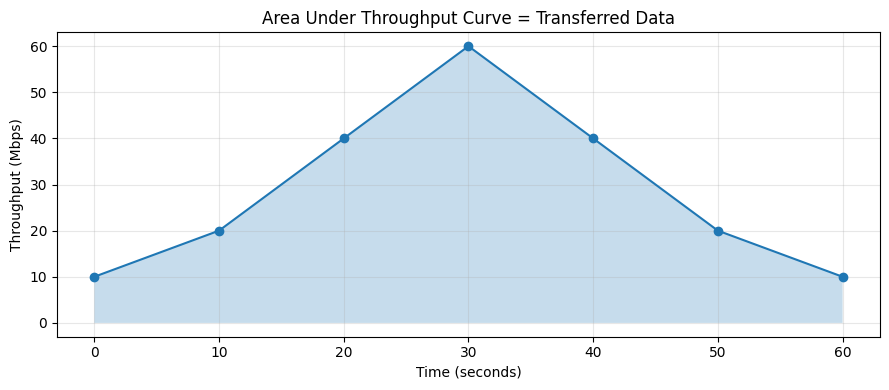

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Instantaneous throughput samples taken every 10 seconds.
seconds = np.array([0, 10, 20, 30, 40, 50, 60])
throughput_mbps = np.array([10, 20, 40, 60, 40, 20, 10])

# Mbps × seconds = megabits.
total_megabits = trapezoid(throughput_mbps, x=seconds)

# Eight bits per byte; decimal units.
total_megabytes = total_megabits / 8
duration = seconds[-1] - seconds[0]
average_mbps = total_megabits / duration

print(f"Duration: {duration} seconds")
print(f"Estimated data: {total_megabytes:.2f} MB")
print(f"Average throughput: {average_mbps:.2f} Mbps")

plt.figure(figsize=(9, 4))
plt.plot(seconds, throughput_mbps, marker="o")
plt.fill_between(seconds, throughput_mbps, alpha=0.25)
plt.xlabel("Time (seconds)")
plt.ylabel("Throughput (Mbps)")
plt.title("Area Under Throughput Curve = Transferred Data")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from scipy.stats import ttest_rel

# Each position represents the same branch in both arrays.
# Values are average RTTs in milliseconds.
before = np.array([42, 38, 55, 47, 36, 62, 51, 44, 58, 40])
after = np.array([36, 35, 48, 43, 35, 53, 47, 39, 50, 38])

improvement = before - after

# Test whether average latency AFTER is lower than BEFORE.
result = ttest_rel(after, before, alternative="less")

print(f"Before mean: {before.mean():.2f} ms")
print(f"After mean: {after.mean():.2f} ms")
print(f"Mean improvement: {improvement.mean():.2f} ms")
print(f"p-value: {result.pvalue:.6f}")

if result.pvalue < 0.05:
    print("Evidence of lower average latency after the change.")
else:
    print("Insufficient evidence of lower average latency.")

for branch, improvement_ms in enumerate(improvement, start=1):
    print(f"Branch {branch}: improvement = {improvement_ms:.1f} ms")

Before mean: 47.30 ms
After mean: 42.40 ms
Mean improvement: 4.90 ms
p-value: 0.000107
Evidence of lower average latency after the change.
Branch 1: improvement = 6.0 ms
Branch 2: improvement = 3.0 ms
Branch 3: improvement = 7.0 ms
Branch 4: improvement = 4.0 ms
Branch 5: improvement = 1.0 ms
Branch 6: improvement = 9.0 ms
Branch 7: improvement = 4.0 ms
Branch 8: improvement = 5.0 ms
Branch 9: improvement = 8.0 ms
Branch 10: improvement = 2.0 ms


Dominant frequency: 0.0167 Hz
Estimated repeat interval: 60.0 seconds


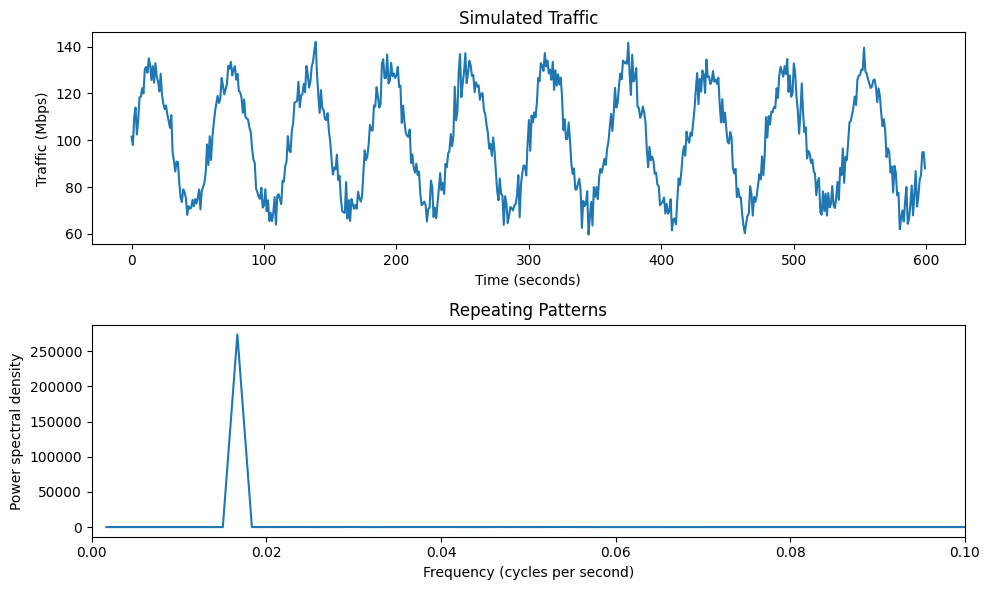

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

rng = np.random.default_rng(42)

# One sample each second for 10 minutes.
sample_interval = 1.0
seconds = np.arange(600) * sample_interval

cycle_seconds = 60

traffic_mbps = (
    100
    + 30 * np.sin(2 * np.pi * seconds / cycle_seconds)
    + rng.normal(0, 5, size=len(seconds))
)

frequencies, power = periodogram(
    traffic_mbps,
    fs=1 / sample_interval
)

# Ignore zero frequency before converting frequency to period.
positive = frequencies > 0
frequencies = frequencies[positive]
power = power[positive]

strongest_index = np.argmax(power)
dominant_frequency = frequencies[strongest_index]
estimated_period = 1 / dominant_frequency

print(f"Dominant frequency: {dominant_frequency:.4f} Hz")
print(f"Estimated repeat interval: {estimated_period:.1f} seconds")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(seconds, traffic_mbps)
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Traffic (Mbps)")
axes[0].set_title("Simulated Traffic")

axes[1].plot(frequencies, power)
axes[1].set_xlim(0, 0.1)
axes[1].set_xlabel("Frequency (cycles per second)")
axes[1].set_ylabel("Power spectral density")
axes[1].set_title("Repeating Patterns")

plt.tight_layout()
plt.show()